In [ ]:
import os
import pickle
import ast
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['figure.figsize'] = [10, 5]

# === SET YOUR EXPERIMENT PATH HERE ===
xp_path = '../dumped/gcd_1layer/1'

# Load and display parameters
params_file = os.path.join(xp_path, 'params.pkl')
params = pickle.load(open(params_file, 'rb'))

key_params = [
    'exp_name', 'exp_id', 'operation', 'architecture',
    'enc_emb_dim', 'dec_emb_dim', 'n_enc_layers', 'n_dec_layers',
    'n_enc_heads', 'n_dec_heads', 'batch_size', 'epoch_size',
    'max_epoch', 'optimizer', 'base', 'maxint', 'eval_size',
]
print("=== Experiment Parameters ===")
for k in key_params:
    if hasattr(params, k):
        print(f"  {k}: {getattr(params, k)}")
        
# adamW(beta1=0.9, beta2=0.98, weight_decay=1)
# decoder only
# feed a fraction of the data ~30%
# maxint = p = smaller
# base = p = smaller
# batch = 128 or no batching


=== Experiment Parameters ===
  exp_name: gcd_1layer
  exp_id: 1
  operation: gcd
  architecture: encoder_decoder
  enc_emb_dim: 128
  dec_emb_dim: 128
  n_enc_layers: 1
  n_dec_layers: 1
  n_enc_heads: 4
  n_dec_heads: 4
  batch_size: 64
  epoch_size: 50000
  max_epoch: 200
  optimizer: adam,lr=0.0001
  base: 1000
  maxint: 100000
  eval_size: 10000


In [5]:
indicator = "valid_arithmetic"
metrics = ["acc", "xe_loss", "perfect", "correct"]

def parse_log(xp_path, max_epoch=None):
    log_file = os.path.join(xp_path, 'train.log')
    res = {m: [] for m in metrics}
    res["train_loss"] = []
    res["per_output_acc"] = {}  # acc_N keys from the last epoch, N = output value
    best_acc, best_epoch = -1.0, -1
    epoch = -1
    train_time, eval_time = 0, 0
    curr_epoch, start_time, end_time = -1, None, None

    with open(log_file, 'rt') as f:
        for line in f:
            try:
                if "============ Starting epoch" in line:
                    parts = line.split()
                    dt = datetime.strptime(parts[2] + ' ' + parts[3], "%m/%d/%y %H:%M:%S")
                    ep = int(parts[parts.index("epoch") + 1])
                    if max_epoch is not None and ep >= max_epoch:
                        break
                    start_time = dt
                    if curr_epoch >= 0 and ep == curr_epoch + 1 and end_time:
                        eval_time += (dt - end_time).total_seconds()
                    curr_epoch = ep

                elif "============ End of epoch" in line:
                    parts = line.split()
                    dt = datetime.strptime(parts[2] + ' ' + parts[3], "%m/%d/%y %H:%M:%S")
                    end_time = dt
                    if start_time:
                        train_time += (dt - start_time).total_seconds()

                elif "- LR:" in line and "- model LR:" not in line:
                    loss_str = line.split()[-4].strip()
                    if loss_str != "predictions.":
                        res["train_loss"].append(float(loss_str) if loss_str != 'nan' else None)

                elif "- model LR:" in line:
                    loss_str = line.split()[-5].strip()
                    res["train_loss"].append(float(loss_str) if loss_str != 'nan' else None)

                else:
                    pos = line.find('__log__:')
                    if pos >= 0:
                        json_str = line[pos + 8:]
                        if ': NaN,' in json_str:
                            json_str = json_str.replace(': NaN,', ': -1.0,')
                        dic = ast.literal_eval(json_str)
                        epoch = dic["epoch"]
                        for m in metrics:
                            key = f"{indicator}_{m}"
                            if key in dic:
                                res[m].append(dic[key])
                        acc = dic.get(f"{indicator}_acc", -1)
                        if acc > best_acc:
                            best_acc = acc
                            best_epoch = epoch
                        # collect per-output-value accuracy
                        res["per_output_acc"] = {
                            k: v for k, v in dic.items()
                            if k.startswith(f"{indicator}_acc_") and v > 0
                        }
            except Exception as e:
                continue

    n_epochs = epoch + 1 if epoch >= 0 else 0
    res["last_epoch"] = epoch
    res["best_acc"] = best_acc
    res["best_epoch"] = best_epoch
    res["train_time_per_epoch"] = int(train_time / n_epochs + 0.5) if n_epochs > 0 else 0
    res["eval_time_per_epoch"] = int(eval_time / n_epochs + 0.5) if n_epochs > 0 else 0
    return res

# Parse the log
data = parse_log(xp_path)

print(f"\n=== Training Summary ===")
print(f"  Total epochs:      {data['last_epoch'] + 1}")
print(f"  Best accuracy:     {data['best_acc']:.2f}% (epoch {data['best_epoch']})")
print(f"  Final accuracy:    {data['acc'][-1]:.2f}%" if data['acc'] else "  No accuracy data")
print(f"  Final xe_loss:     {data['xe_loss'][-1]:.4f}" if data['xe_loss'] else "  No loss data")
print(f"  Train time/epoch:  {data['train_time_per_epoch']}s")
print(f"  Eval time/epoch:   {data['eval_time_per_epoch']}s")


=== Training Summary ===
  Total epochs:      200
  Best accuracy:     85.16% (epoch 100)
  Final accuracy:    84.10%
  Final xe_loss:     0.7282
  Train time/epoch:  12s
  Eval time/epoch:   2s


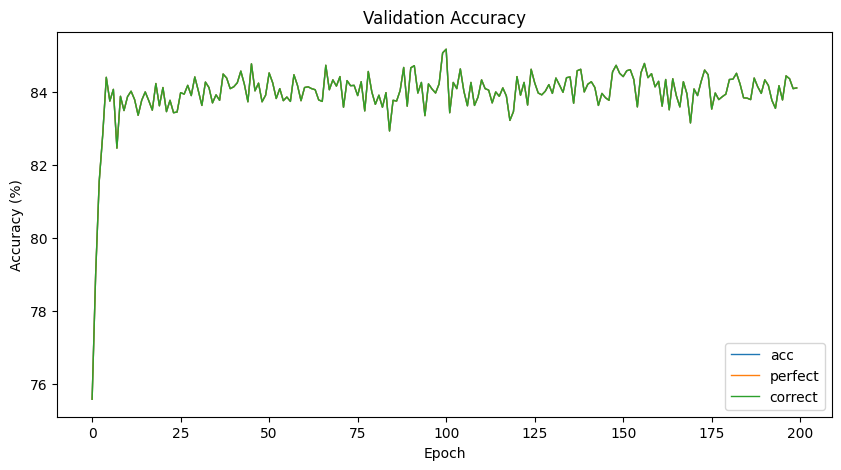

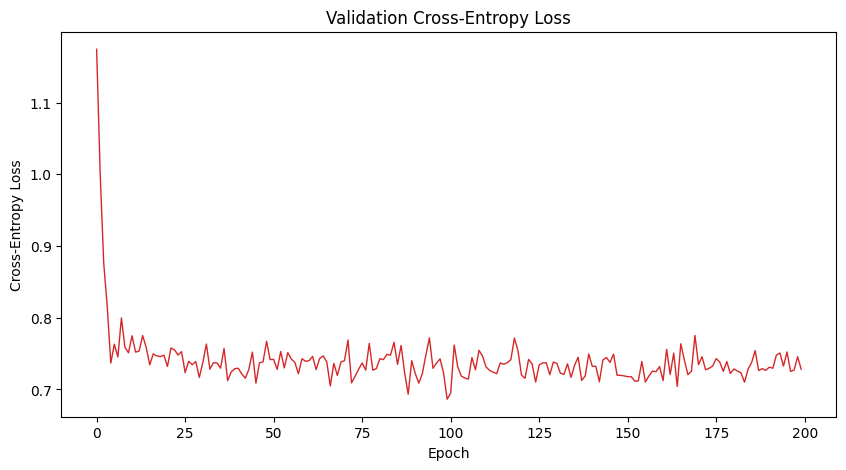

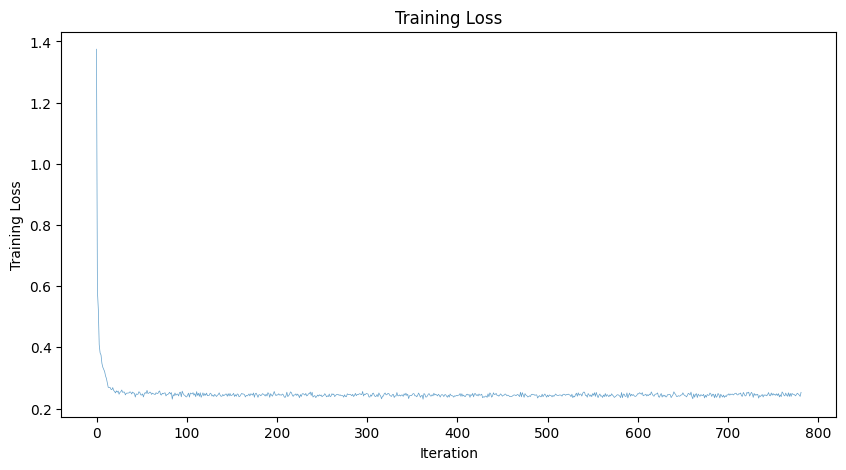

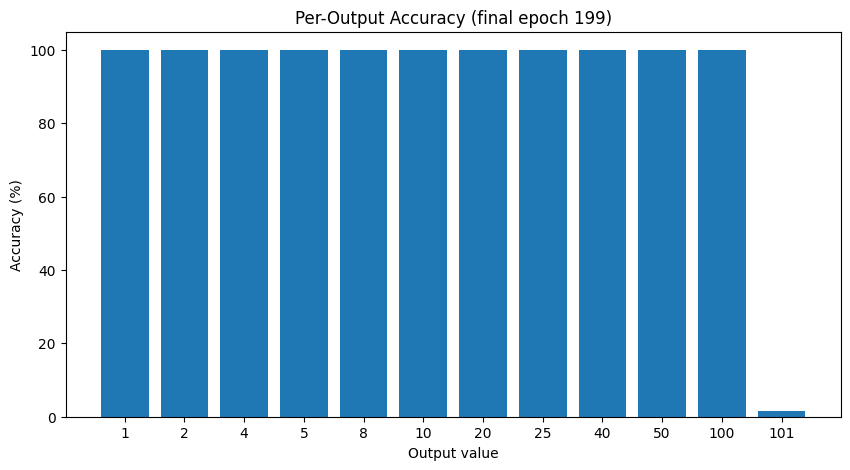

In [6]:
# --- Accuracy curves (acc, perfect, correct) ---
fig, ax = plt.subplots()
epochs = range(len(data["acc"]))
for m in ["acc", "perfect", "correct"]:
    if data[m]:
        ax.plot(epochs, data[m], label=m, linewidth=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Validation Accuracy")
ax.legend()
plt.show()

# --- Cross-entropy loss ---
if data["xe_loss"]:
    fig, ax = plt.subplots()
    ax.plot(epochs, data["xe_loss"], linewidth=1, color="tab:red")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.set_title("Validation Cross-Entropy Loss")
    plt.show()

# --- Training loss (per iteration) ---
if data["train_loss"]:
    fig, ax = plt.subplots()
    losses = [v for v in data["train_loss"] if v is not None]
    ax.plot(losses, linewidth=0.5, alpha=0.7)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss")
    plt.show()

# --- Per-output-value accuracy at final epoch ---
if data["per_output_acc"]:
    prefix = f"{indicator}_acc_"
    output_accs = {int(k[len(prefix):]): v for k, v in data["per_output_acc"].items()}
    outputs = sorted(output_accs.keys())
    values = [output_accs[o] for o in outputs]
    fig, ax = plt.subplots()
    ax.bar([str(o) for o in outputs], values)
    ax.set_xlabel("Output value")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"Per-Output Accuracy (final epoch {data['last_epoch']})")
    plt.show()